In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Flatten, Conv2D, MaxPooling2D, Dropout
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
print("All required libraries imported successfully.")

All required libraries imported successfully.


**Data Preparation**

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Training Data:", x_train.shape, y_train_cat.shape)
print("Testing Data:", x_test.shape, y_test_cat.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Training Data: (50000, 32, 32, 3) (50000, 10)
Testing Data: (10000, 32, 32, 3) (10000, 10)


**ANN Model**

In [3]:
def build_ann(optimizer='adam', activation='relu'):
    model = Sequential([
        Flatten(input_shape=(32, 32, 3)),
        Dense(512, activation=activation),
        Dense(256, activation=activation),
        Dense(128, activation=activation),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

ann_model = build_ann(optimizer=Adam())
ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

**CNN Model**

In [4]:
def build_cnn(optimizer='adam'):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same',
               input_shape=(32,32,3)),
        MaxPooling2D((2,2)),

        Conv2D(64, (5,5), activation='relu', padding='same'),
        MaxPooling2D((2,2)),

        Conv2D(128, (7,7), activation='relu', padding='same'),
        MaxPooling2D((2,2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

cnn_model = build_cnn(optimizer=Adam())
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 717,258 (2.74 MB)

 Trainable params: 717,258 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

**Train ANN Model**

In [5]:
ann_model = build_ann(optimizer=Adam())

start_time = time.time()
ann_history = ann_model.fit(
    x_train, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)
ann_training_time = time.time() - start_time
print("ANN Training Time (seconds):", ann_training_time)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.2650 - loss: 2.0367 - val_accuracy: 0.3694 - val_loss: 1.7827
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.3838 - loss: 1.7215 - val_accuracy: 0.4074 - val_loss: 1.6780
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.4120 - loss: 1.6375 - val_accuracy: 0.4209 - val_loss: 1.6237
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.4392 - loss: 1.5627 - val_accuracy: 0.4416 - val_loss: 1.5698
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.4569 - loss: 1.5101 - val_accuracy: 0.4523 - val_loss: 1.5501
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.4699 - loss: 1.4879 - val_accuracy: 0.4446 - val_loss: 1.5508
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.4825 - loss: 1.4375 - val_accuracy: 0.4704 - val_loss: 1.5018
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.4953 - loss: 1.4110 - 

**Train CNN Model**

In [6]:
cnn_model = build_cnn(optimizer=Adam())

start_time = time.time()
cnn_history = cnn_model.fit(
    x_train, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

cnn_training_time = time.time() - start_time
print("CNN Training Time (seconds):", cnn_training_time)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 318s 506ms/step - accuracy: 0.2677 - loss: 1.9497 - val_accuracy: 0.5236 - val_loss: 1.3382
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 314s 493ms/step - accuracy: 0.5227 - loss: 1.3446 - val_accuracy: 0.5862 - val_loss: 1.1546
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 308s 493ms/step - accuracy: 0.6081 - loss: 1.1146 - val_accuracy: 0.6424 - val_loss: 1.0240
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 322s 493ms/step - accuracy: 0.6667 - loss: 0.9566 - val_accuracy: 0.6858 - val_loss: 0.8965
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 321s 493ms/step - accuracy: 0.7125 - loss: 0.8183 - val_accuracy: 0.7082 - val_loss: 0.8355
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 307s 492ms/step - accuracy: 0.7466 - loss: 0.7263 - val_accuracy: 0.7043 - val_loss: 0.8477
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 321s 491ms/step - accuracy: 0.7763 - loss: 0.6419 - val_accuracy: 0.7170 - val_loss: 0.8381
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 307s 492ms/step - accuracy: 0.8031 -

**Model Evaluation (ANN + CNN)**

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test, y_test_cat, verbose=0)

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test, y_test_cat, verbose=0)

print("ANN Test Accuracy:", ann_test_acc)
print("CNN Test Accuracy:", cnn_test_acc)

ANN Test Accuracy: 0.48410001397132874
CNN Test Accuracy: 0.7184000015258789


**Confusion Matrix & Classification Metrics**

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

ANN Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.62      0.55      1000
           1       0.58      0.59      0.58      1000
           2       0.38      0.40      0.39      1000
           3       0.33      0.34      0.33      1000
           4       0.43      0.42      0.42      1000
           5       0.39      0.39      0.39      1000
           6       0.51      0.54      0.52      1000
           7       0.62      0.47      0.53      1000
           8       0.57      0.66      0.61      1000
           9       0.60      0.43      0.50      1000

    accuracy                           0.48     10000
   macro avg       0.49      0.48      0.48     10000
weighted avg       0.49      0.48      0.48     10000



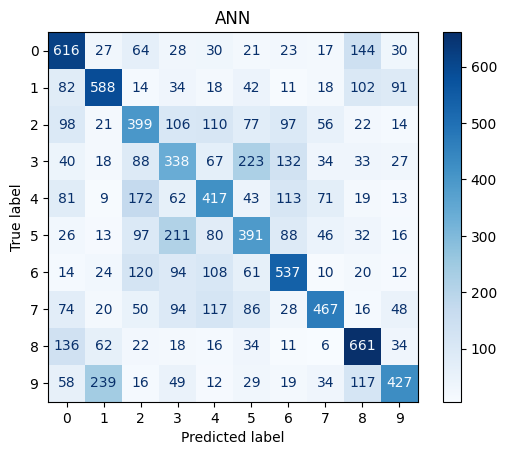

313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step

CNN Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.73      0.76      1000
           1       0.77      0.90      0.83      1000
           2       0.68      0.58      0.62      1000
           3       0.53      0.48      0.50      1000
           4       0.70      0.67      0.68      1000
           5       0.53      0.75      0.62      1000
           6       0.81      0.76      0.78      1000
           7       0.77      0.77      0.77      1000
           8       0.84      0.81      0.82      1000
           9       0.86      0.74      0.80      1000

    accuracy                           0.72     10000
   macro avg       0.73      0.72      0.72     10000
weighted avg       0.73      0.72      0.72     10000



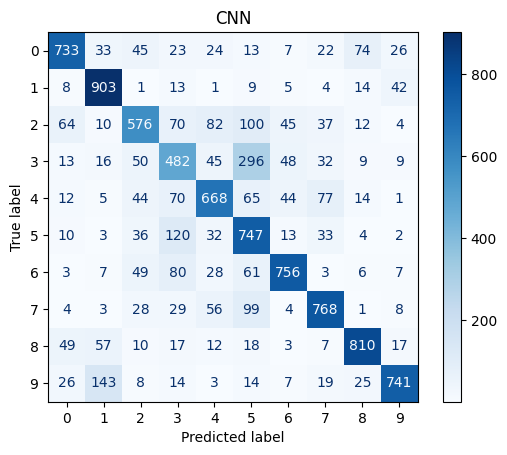

In [8]:
def evaluate_model(model, x_test, y_test_cat, title):
    y_pred = np.argmax(model.predict(x_test), axis=1)
    y_true = np.argmax(y_test_cat, axis=1)

    print(f"\n{title} Classification Report:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.show()

evaluate_model(ann_model, x_test, y_test_cat, "ANN")

evaluate_model(cnn_model, x_test, y_test_cat, "CNN")

**Training vs Validation Curves**

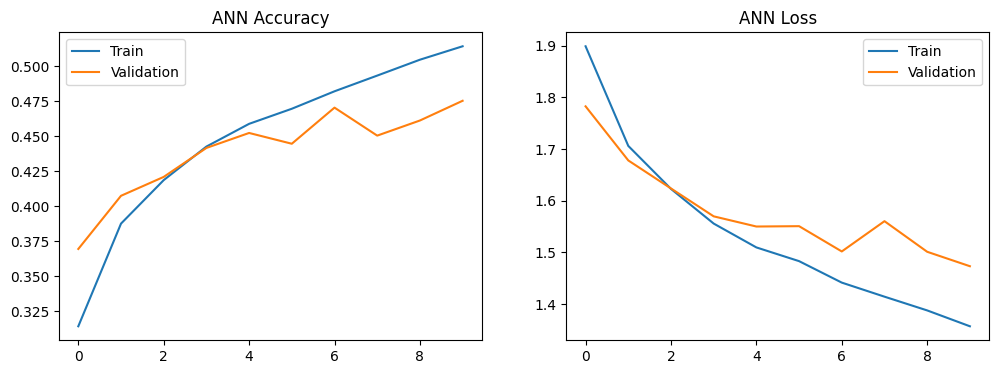

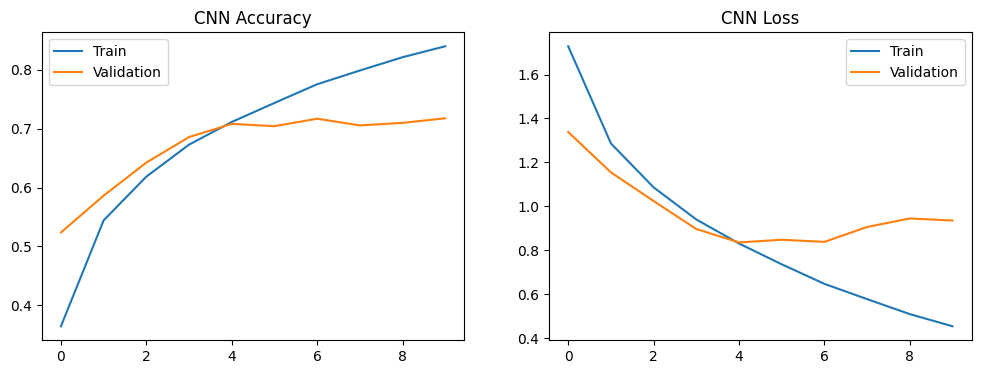

In [9]:
def plot_history(history, title):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(f'{title} Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(f'{title} Loss')
    plt.legend()

    plt.show()

plot_history(ann_history, "ANN")
plot_history(cnn_history, "CNN")

**Misclassified Images (CNN)**

In [10]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 69ms/step


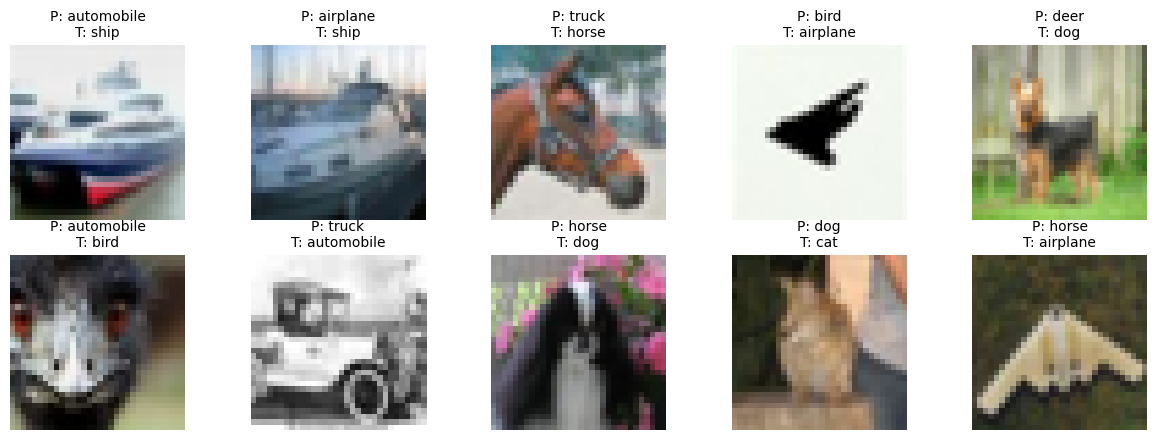

In [11]:
y_pred = np.argmax(cnn_model.predict(x_test), axis=1)
y_true = np.argmax(y_test_cat, axis=1)

misclassified = np.where(y_pred != y_true)[0][:10]

plt.figure(figsize=(15,5))
for i, idx in enumerate(misclassified):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[idx])

    pred_label = class_names[y_pred[idx]]
    true_label = class_names[y_true[idx]]

    plt.title(f"P: {pred_label}\nT: {true_label}", fontsize=10)
    plt.axis('off')

plt.show()

**Final Comparison Table**

In [12]:
print("Model Comparison Summary\n")
print("Model | Parameters | Test Accuracy | Training Time")
print("---------------------------------------------------")
print(f"ANN  | {ann_model.count_params()} | {ann_test_acc:.4f} | {ann_training_time:.2f}s")
print(f"CNN  | {cnn_model.count_params()} | {cnn_test_acc:.4f} | {cnn_training_time:.2f}s")

Model Comparison Summary

Model | Parameters | Test Accuracy | Training Time
---------------------------------------------------
ANN  | 1738890 | 0.4841 | 189.25s
CNN  | 717258 | 0.7184 | 3153.60s


**Summary**

In this  assignment, image classification was performed on the CIFAR-10 dataset using both an Artificial Neural Network (ANN) and a Convolutional Neural Network (CNN) in order to compare their learning behavior and performance. The CIFAR-10 dataset consists of 32×32 color images belonging to ten different object classes. As part of data preprocessing, all images were normalized to the range [0,1] and the class labels were converted into one-hot encoded format.

An ANN model was implemented as a baseline using a Multi-Layer Perceptron architecture. The input images were flattened into one-dimensional vectors and passed through three fully connected hidden layers with ReLU activation, followed by a Softmax output layer. Although the ANN was able to learn basic patterns, it treated image data as plain numerical input and failed to capture spatial relationships between pixels.

To overcome this limitation, a CNN model was designed specifically for image data. The CNN architecture included three convolutional layers with different kernel sizes to extract spatial and hierarchical features from the images. MaxPooling layers were used to reduce dimensionality, and Dropout was applied to reduce overfitting. The CNN was then connected to fully connected layers for final classification.

Both ANN and CNN models were trained using the same dataset, optimizer, loss function, and evaluation metrics to ensure a fair comparison. Model performance was analyzed using training and validation accuracy, loss curves, test accuracy, confusion matrices, classification reports, and misclassified image visualization. Training time and parameter count were also recorded for comparison.

The experimental results showed that the CNN achieved higher accuracy and better generalization than the ANN. This clearly demonstrates that CNNs are more suitable for image classification tasks because they can automatically learn spatial features such as edges, shapes, and textures, whereas ANNs lack this capability. Overall, this experiment confirms the effectiveness of CNNs over ANNs for computer vision applications.